In [5]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import pandas as pd
import json

repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [6]:
def count_sign_changes(delta_x):
    signs = np.sign(delta_x)
    sign_changes = np.sum(np.diff(signs) != 0)
    return sign_changes

def is_bifurcation(delta_x_list):
    counts = [count_sign_changes(delta_x) for delta_x in delta_x_list]
    unique_counts = set(counts)
    return len(unique_counts) > 1

def metastability_score(f, df, x_grid, tau):
    distance_to_critical = f(x_grid)**2 + df(x_grid)**2
    normalized_distance = distance_to_critical * tau**2 # between 0 (critical) and 1 (linear dynamics)
    return 1-np.min(normalized_distance) 

In [7]:
json_path = cwd / "5CV_Passive_late.json"
with open(json_path, "r") as f:
    data_5cv = json.load(f)
    results_cv = data_5cv.get("results_cv")
    print("Loaded results_cv:", results_cv)

Loaded results_cv: ['NonLinear1', 'NonLinear1', 'NonLinear1', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation']


# Bifurcation Probability & Metastability Scoring 

### Via Particle Density Estimation for the best model **per participant**

Loaded results_cv: ['NonLinear1', 'NonLinear1', 'NonLinear1', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'GainModulation', 'NonLinear1', 'GainModulation']
part 0 lets go, best model is NonLinear1
Max threshold: 1.22


Grid Search for Part 0:   0%|          | 0/21 [00:00<?, ?it/s]

Part 0 has a 0.0000 probability of bifurcation.
Part 0 has a 0.0156 metastability score.
part 1 lets go, best model is NonLinear1
Max threshold: 1.30


Grid Search for Part 1:   0%|          | 0/21 [00:00<?, ?it/s]

Part 1 has a 0.0000 probability of bifurcation.
Part 1 has a 0.7004 metastability score.
part 2 lets go, best model is NonLinear1
Max threshold: 1.43


Grid Search for Part 2:   0%|          | 0/21 [00:00<?, ?it/s]

Part 2 has a 0.0000 probability of bifurcation.
Part 2 has a 0.7317 metastability score.
part 3 lets go, best model is GainModulation
Max threshold: 1.39
Fitted threshold from parent model: 0.94


Tau grid for part 3:   0%|          | 0/21 [00:00<?, ?it/s]

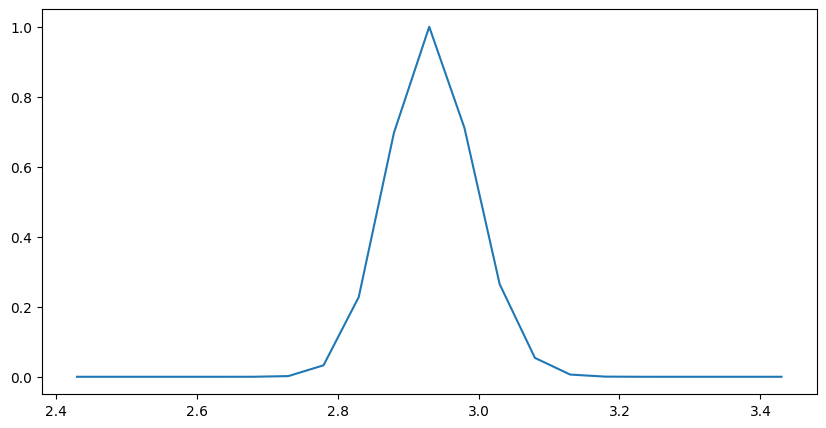

2D Search (Tau) for Part 3: 0it [00:00, ?it/s]

2.7299703289205732 is a good enough tau
2.7799703289205735 is a good enough tau
2.8299703289205733 is a good enough tau
2.8799703289205736 is a good enough tau
2.9299703289205734 is a good enough tau
2.9799703289205732 is a good enough tau
3.0299703289205735 is a good enough tau
3.0799703289205733 is a good enough tau
3.1299703289205736 is a good enough tau
Part 3 has a 0.0001 probability of bifurcation.
Part 3 has a 0.9736 metastability score.
part 4 lets go, best model is GainModulation
Max threshold: 1.51
Fitted threshold from parent model: 1.04


Tau grid for part 4:   0%|          | 0/21 [00:00<?, ?it/s]

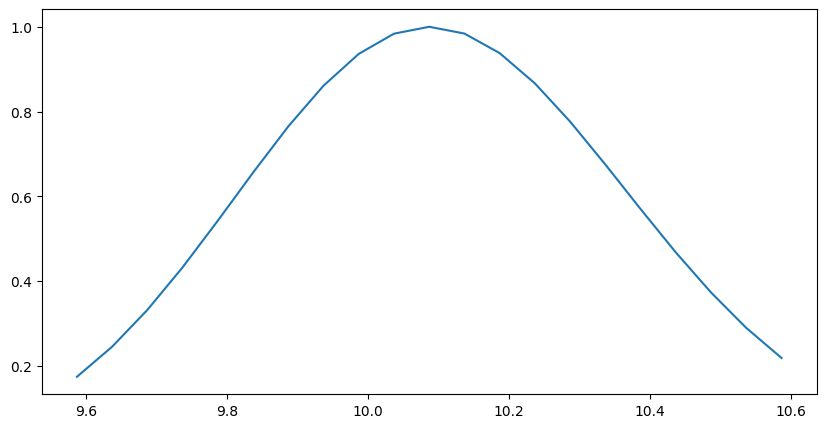

2D Search (Tau) for Part 4: 0it [00:00, ?it/s]

9.58699235757769 is a good enough tau
9.636992357577691 is a good enough tau
9.68699235757769 is a good enough tau
9.73699235757769 is a good enough tau
9.78699235757769 is a good enough tau
9.83699235757769 is a good enough tau
9.886992357577691 is a good enough tau
9.93699235757769 is a good enough tau
9.98699235757769 is a good enough tau
10.03699235757769 is a good enough tau
10.08699235757769 is a good enough tau
10.136992357577691 is a good enough tau
10.18699235757769 is a good enough tau
10.23699235757769 is a good enough tau
10.28699235757769 is a good enough tau
10.33699235757769 is a good enough tau
10.386992357577691 is a good enough tau
10.43699235757769 is a good enough tau
10.48699235757769 is a good enough tau
10.53699235757769 is a good enough tau
10.58699235757769 is a good enough tau
Part 4 has a 0.0026 probability of bifurcation.
Part 4 has a 0.9189 metastability score.
part 5 lets go, best model is NonLinear1
Max threshold: 1.30


Grid Search for Part 5:   0%|          | 0/21 [00:00<?, ?it/s]

Part 5 has a 0.0000 probability of bifurcation.
Part 5 has a 0.0598 metastability score.
part 6 lets go, best model is GainModulation
Max threshold: 1.54
Fitted threshold from parent model: 0.97


Tau grid for part 6:   0%|          | 0/21 [00:00<?, ?it/s]

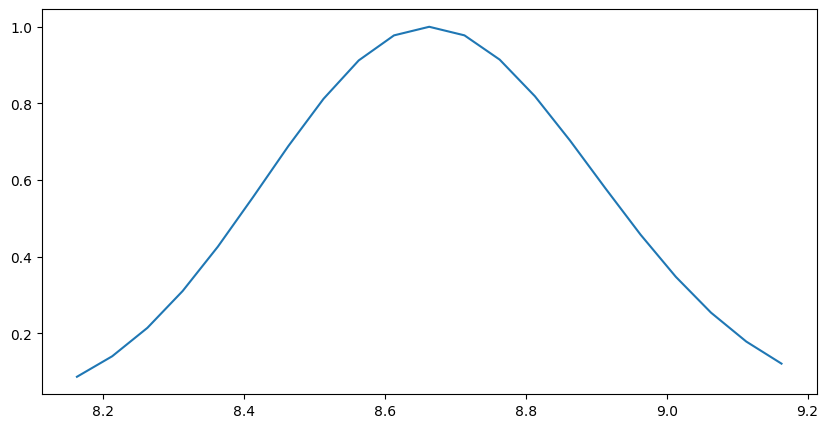

2D Search (Tau) for Part 6: 0it [00:00, ?it/s]

8.163005340304451 is a good enough tau
8.213005340304452 is a good enough tau
8.263005340304451 is a good enough tau
8.313005340304452 is a good enough tau
8.36300534030445 is a good enough tau
8.413005340304451 is a good enough tau
8.463005340304452 is a good enough tau
8.513005340304451 is a good enough tau
8.563005340304452 is a good enough tau
8.61300534030445 is a good enough tau
8.663005340304451 is a good enough tau
8.713005340304452 is a good enough tau
8.763005340304451 is a good enough tau
8.813005340304452 is a good enough tau
8.86300534030445 is a good enough tau
8.913005340304451 is a good enough tau
8.963005340304452 is a good enough tau
9.013005340304451 is a good enough tau
9.063005340304452 is a good enough tau
9.11300534030445 is a good enough tau
9.163005340304451 is a good enough tau
Part 6 has a 1.0000 probability of bifurcation.
Part 6 has a 1.0000 metastability score.
part 7 lets go, best model is GainModulation
Max threshold: 1.31
Fitted threshold from parent mo

Tau grid for part 7:   0%|          | 0/21 [00:00<?, ?it/s]

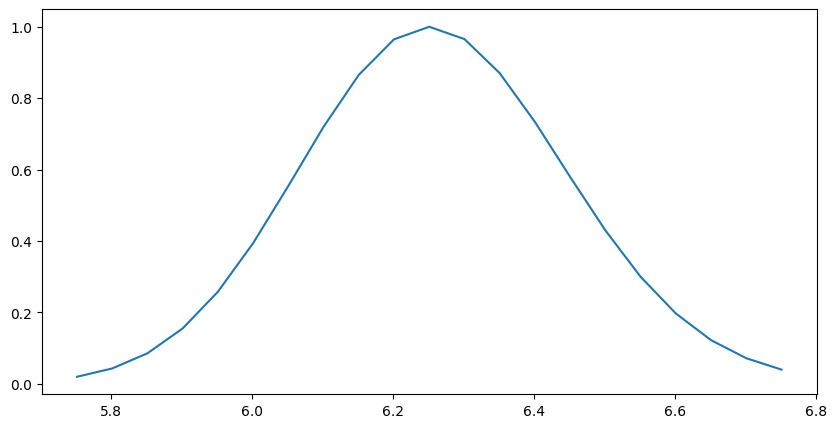

2D Search (Tau) for Part 7: 0it [00:00, ?it/s]

5.751150577577884 is a good enough tau
5.801150577577884 is a good enough tau
5.851150577577884 is a good enough tau
5.9011505775778845 is a good enough tau
5.951150577577884 is a good enough tau
6.001150577577884 is a good enough tau
6.051150577577884 is a good enough tau
6.101150577577884 is a good enough tau
6.1511505775778845 is a good enough tau
6.201150577577884 is a good enough tau
6.251150577577884 is a good enough tau
6.301150577577884 is a good enough tau
6.351150577577885 is a good enough tau
6.4011505775778845 is a good enough tau
6.451150577577884 is a good enough tau
6.501150577577884 is a good enough tau
6.551150577577884 is a good enough tau
6.601150577577885 is a good enough tau
6.6511505775778845 is a good enough tau
6.701150577577884 is a good enough tau
6.751150577577884 is a good enough tau
Part 7 has a 0.0000 probability of bifurcation.
Part 7 has a 0.8848 metastability score.
part 8 lets go, best model is GainModulation
Max threshold: 1.38
Fitted threshold from p

Tau grid for part 8:   0%|          | 0/21 [00:00<?, ?it/s]

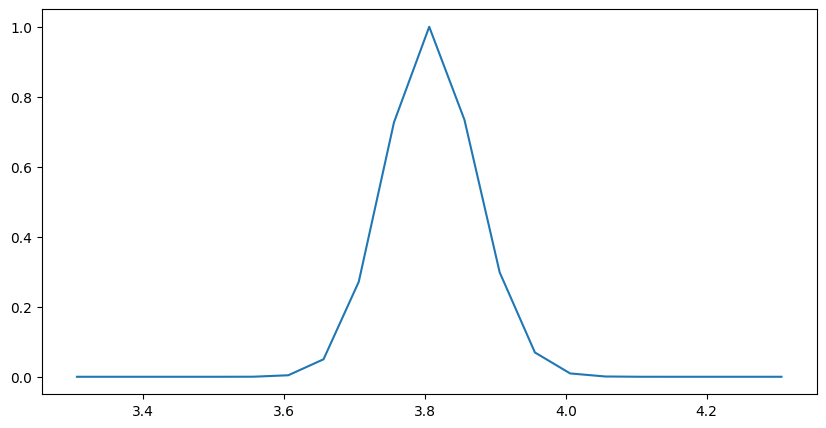

2D Search (Tau) for Part 8: 0it [00:00, ?it/s]

3.60610013437444 is a good enough tau
3.6561001343744404 is a good enough tau
3.70610013437444 is a good enough tau
3.7561001343744405 is a good enough tau
3.8061001343744403 is a good enough tau
3.85610013437444 is a good enough tau
3.9061001343744404 is a good enough tau
3.95610013437444 is a good enough tau
4.0061001343744405 is a good enough tau
Part 8 has a 0.0000 probability of bifurcation.
Part 8 has a 0.9748 metastability score.
part 9 lets go, best model is GainModulation
Max threshold: 1.53
Fitted threshold from parent model: 0.89


Tau grid for part 9:   0%|          | 0/21 [00:00<?, ?it/s]

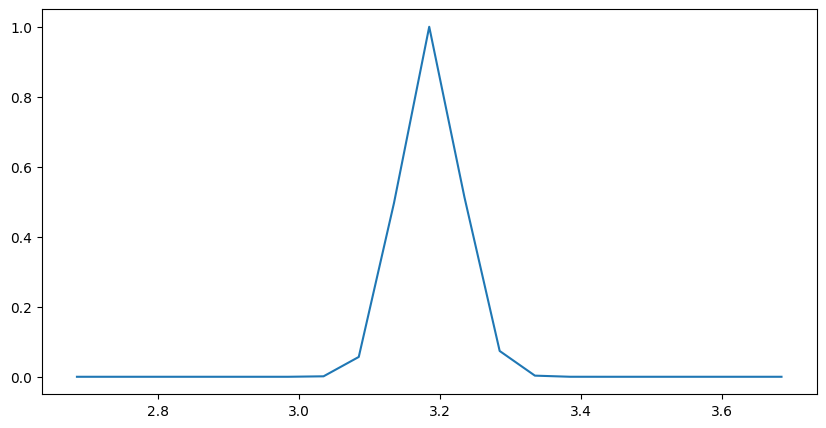

2D Search (Tau) for Part 9: 0it [00:00, ?it/s]

3.034718097707261 is a good enough tau
3.084718097707261 is a good enough tau
3.1347180977072613 is a good enough tau
3.184718097707261 is a good enough tau
3.234718097707261 is a good enough tau
3.284718097707261 is a good enough tau
3.334718097707261 is a good enough tau
Part 9 has a 0.9851 probability of bifurcation.
Part 9 has a 1.0000 metastability score.
part 10 lets go, best model is GainModulation
Max threshold: 1.48
Fitted threshold from parent model: 1.06


Tau grid for part 10:   0%|          | 0/21 [00:00<?, ?it/s]

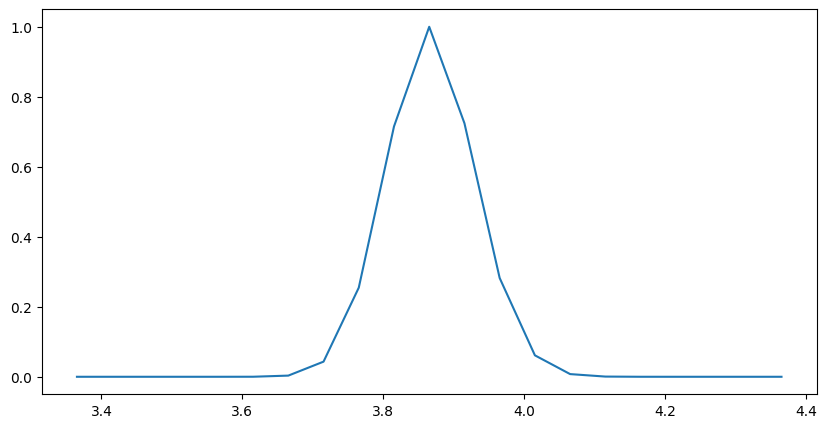

2D Search (Tau) for Part 10: 0it [00:00, ?it/s]

3.6652782166106213 is a good enough tau
3.715278216610621 is a good enough tau
3.7652782166106213 is a good enough tau
3.815278216610621 is a good enough tau
3.865278216610621 is a good enough tau
3.9152782166106213 is a good enough tau
3.965278216610621 is a good enough tau
4.015278216610621 is a good enough tau
4.065278216610621 is a good enough tau
Part 10 has a 0.0000 probability of bifurcation.
Part 10 has a 0.8932 metastability score.
part 11 lets go, best model is GainModulation
Max threshold: 1.40
Fitted threshold from parent model: 0.98


Tau grid for part 11:   0%|          | 0/21 [00:00<?, ?it/s]

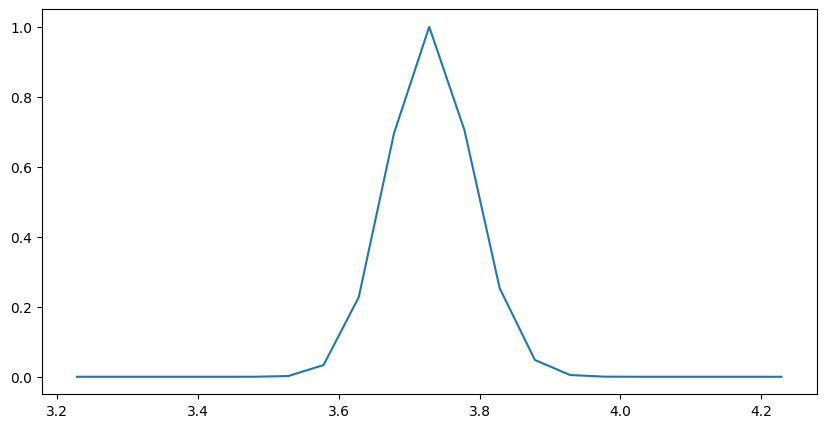

2D Search (Tau) for Part 11: 0it [00:00, ?it/s]

3.5285658243525626 is a good enough tau
3.578565824352563 is a good enough tau
3.6285658243525627 is a good enough tau
3.678565824352563 is a good enough tau
3.728565824352563 is a good enough tau
3.7785658243525626 is a good enough tau
3.828565824352563 is a good enough tau
3.8785658243525627 is a good enough tau
3.928565824352563 is a good enough tau
Part 11 has a 0.0009 probability of bifurcation.
Part 11 has a 0.9828 metastability score.
part 12 lets go, best model is GainModulation
Max threshold: 1.42
Fitted threshold from parent model: 0.71


Tau grid for part 12:   0%|          | 0/21 [00:00<?, ?it/s]

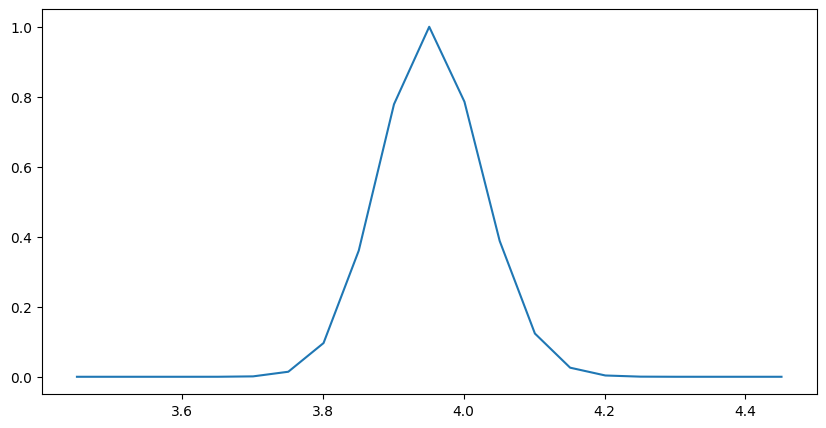

2D Search (Tau) for Part 12: 0it [00:00, ?it/s]

3.7011404542657496 is a good enough tau
3.7511404542657494 is a good enough tau
3.801140454265749 is a good enough tau
3.8511404542657495 is a good enough tau
3.9011404542657493 is a good enough tau
3.951140454265749 is a good enough tau
4.001140454265749 is a good enough tau
4.051140454265749 is a good enough tau
4.1011404542657495 is a good enough tau
4.151140454265749 is a good enough tau
4.201140454265749 is a good enough tau
Part 12 has a 0.0569 probability of bifurcation.
Part 12 has a 0.9905 metastability score.
part 13 lets go, best model is GainModulation
Max threshold: 1.56
Fitted threshold from parent model: 0.93


Tau grid for part 13:   0%|          | 0/21 [00:00<?, ?it/s]

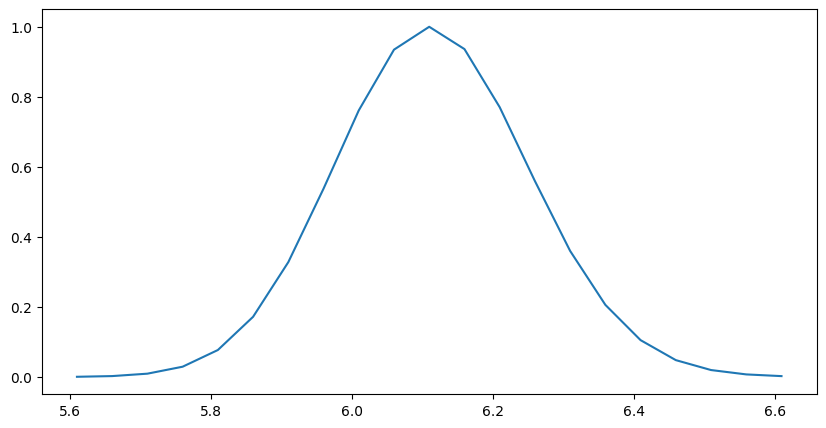

2D Search (Tau) for Part 13: 0it [00:00, ?it/s]

5.6594192710647535 is a good enough tau
5.709419271064753 is a good enough tau
5.759419271064754 is a good enough tau
5.809419271064754 is a good enough tau
5.859419271064754 is a good enough tau
5.9094192710647535 is a good enough tau
5.959419271064753 is a good enough tau
6.009419271064754 is a good enough tau
6.059419271064754 is a good enough tau
6.109419271064754 is a good enough tau
6.1594192710647535 is a good enough tau
6.209419271064753 is a good enough tau
6.259419271064754 is a good enough tau
6.309419271064754 is a good enough tau
6.359419271064754 is a good enough tau
6.4094192710647535 is a good enough tau
6.459419271064753 is a good enough tau
6.509419271064754 is a good enough tau
6.559419271064754 is a good enough tau
6.609419271064754 is a good enough tau
Part 13 has a 0.9961 probability of bifurcation.
Part 13 has a 1.0000 metastability score.
part 14 lets go, best model is GainModulation
Max threshold: 1.36
Fitted threshold from parent model: 0.59


Tau grid for part 14:   0%|          | 0/21 [00:00<?, ?it/s]

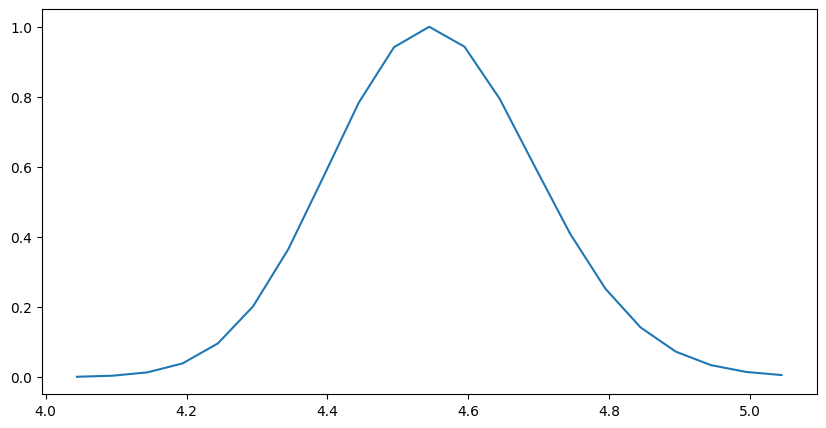

2D Search (Tau) for Part 14: 0it [00:00, ?it/s]

4.094491456573107 is a good enough tau
4.144491456573107 is a good enough tau
4.1944914565731075 is a good enough tau
4.244491456573107 is a good enough tau
4.294491456573107 is a good enough tau
4.344491456573107 is a good enough tau
4.394491456573107 is a good enough tau
4.4444914565731075 is a good enough tau
4.494491456573107 is a good enough tau
4.544491456573107 is a good enough tau
4.594491456573107 is a good enough tau
4.644491456573107 is a good enough tau
4.6944914565731075 is a good enough tau
4.744491456573107 is a good enough tau
4.794491456573107 is a good enough tau
4.844491456573107 is a good enough tau
4.894491456573107 is a good enough tau
4.9444914565731075 is a good enough tau
4.994491456573107 is a good enough tau
5.044491456573107 is a good enough tau
Part 14 has a 0.3898 probability of bifurcation.
Part 14 has a 0.9991 metastability score.
part 15 lets go, best model is GainModulation
Max threshold: 1.42
Fitted threshold from parent model: 0.51


Tau grid for part 15:   0%|          | 0/21 [00:00<?, ?it/s]

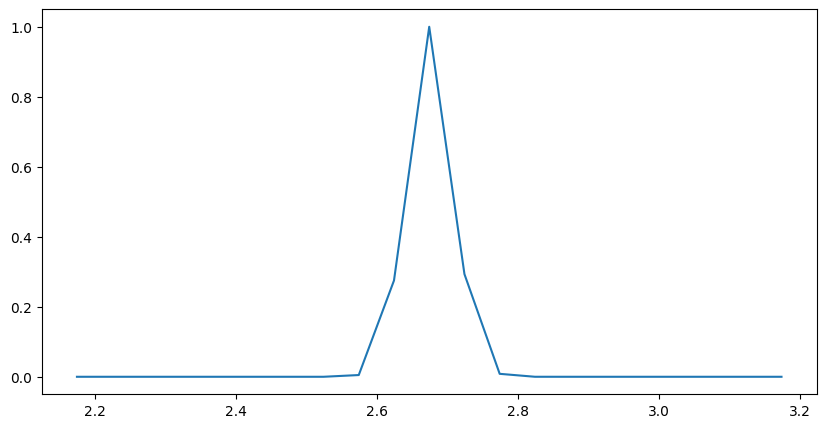

2D Search (Tau) for Part 15: 0it [00:00, ?it/s]

2.5740891504625685 is a good enough tau
2.6240891504625687 is a good enough tau
2.6740891504625686 is a good enough tau
2.724089150462569 is a good enough tau
2.7740891504625687 is a good enough tau
Part 15 has a 0.0000 probability of bifurcation.
Part 15 has a 0.8383 metastability score.
part 16 lets go, best model is GainModulation
Max threshold: 1.42
Fitted threshold from parent model: 0.50


Tau grid for part 16:   0%|          | 0/21 [00:00<?, ?it/s]

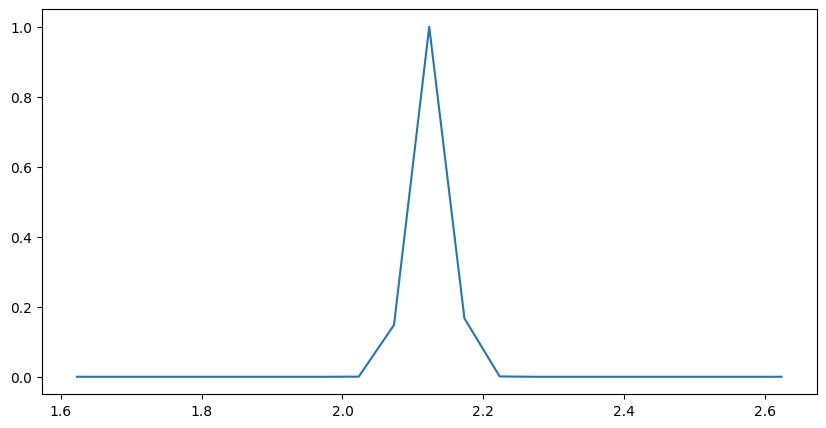

2D Search (Tau) for Part 16: 0it [00:00, ?it/s]

2.0731540376037305 is a good enough tau
2.1231540376037303 is a good enough tau
2.17315403760373 is a good enough tau
Part 16 has a 0.0000 probability of bifurcation.
Part 16 has a 0.9425 metastability score.
part 17 lets go, best model is GainModulation
Max threshold: 1.40
Fitted threshold from parent model: 0.59


Tau grid for part 17:   0%|          | 0/21 [00:00<?, ?it/s]

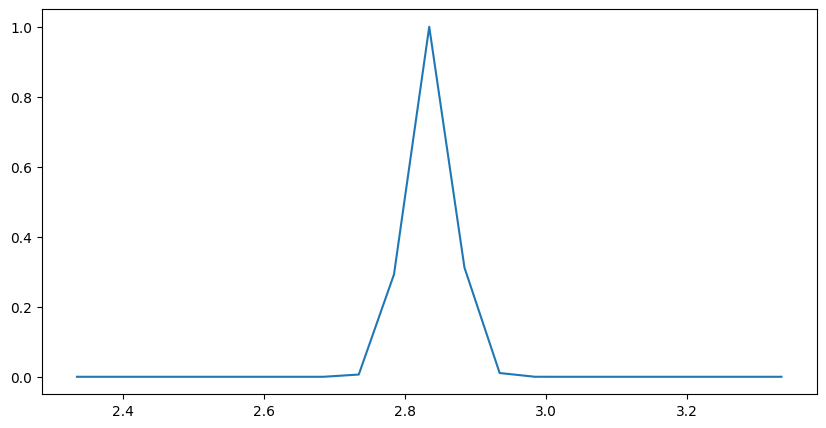

2D Search (Tau) for Part 17: 0it [00:00, ?it/s]

2.734763903903411 is a good enough tau
2.784763903903411 is a good enough tau
2.834763903903411 is a good enough tau
2.884763903903411 is a good enough tau
2.934763903903411 is a good enough tau
Part 17 has a 0.0000 probability of bifurcation.
Part 17 has a 0.9368 metastability score.
part 18 lets go, best model is NonLinear1
Max threshold: 1.49


Grid Search for Part 18:   0%|          | 0/21 [00:00<?, ?it/s]

Part 18 has a 0.0000 probability of bifurcation.
Part 18 has a 0.9138 metastability score.
part 19 lets go, best model is GainModulation
Max threshold: 1.51
Fitted threshold from parent model: 0.54


Tau grid for part 19:   0%|          | 0/21 [00:00<?, ?it/s]

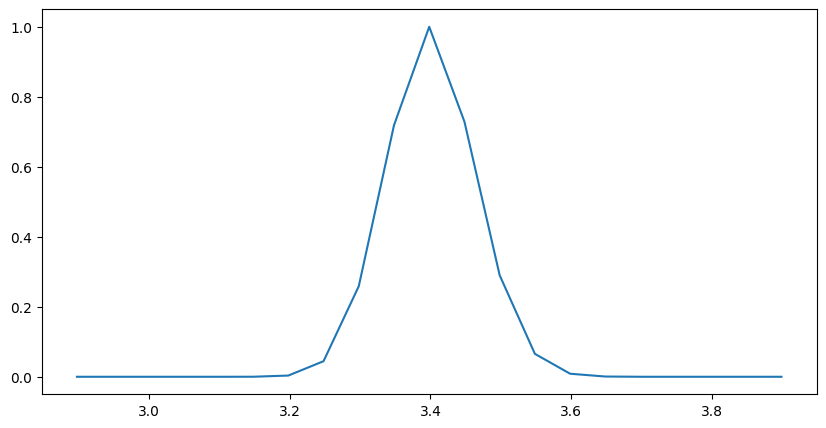

2D Search (Tau) for Part 19: 0it [00:00, ?it/s]

3.1982967417803385 is a good enough tau
3.248296741780339 is a good enough tau
3.2982967417803386 is a good enough tau
3.348296741780339 is a good enough tau
3.3982967417803387 is a good enough tau
3.4482967417803385 is a good enough tau
3.498296741780339 is a good enough tau
3.5482967417803386 is a good enough tau
3.598296741780339 is a good enough tau
Part 19 has a 0.0016 probability of bifurcation.
Part 19 has a 0.9917 metastability score.


In [8]:
task = "Passive"
file_path = Path(f'Fit_{task}_late')
sub_file_path = "MetaBifurc_AllModels_21^2"

# Define the summary path clearly and load existing progress 
summary_path = file_path / sub_file_path / "metabifurc.csv"
if summary_path.exists():
    print(f"Found existing summary at {summary_path}. Loading progress...")
    existing_df = pd.read_csv(summary_path, index_col=0)
    bifurcation_prob = existing_df["probability_of_bifurcation"].to_dict()
    metastability_scores = existing_df["metastability_score"].to_dict()
    print(bifurcation_prob)
    print(metastability_scores)
else:
    bifurcation_prob, metastability_scores = {}, {}

# load the name of the best model for each participant
json_path = cwd / f"5CV_{task}_late.json"
with open(json_path, "r") as f:
    data_5cv = json.load(f)
    results_cv = data_5cv.get("results_cv")
    print("Loaded results_cv:", results_cv)

    
for part in range(20):
    best_model = results_cv[part]
    print(f'part {part} lets go, best model is {best_model}')

    # --- SKIP if already processed --- 
    if part in bifurcation_prob:
        print(f">>> Part {part} already exists in CSV. Skipping...")
        continue
    
    # --- Load Data ---
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref
    
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # --- Input Definition ---
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(150)))
    input_train = {cat: np.stack([one_input for _ in range(state_train[cat].shape[0])]) for cat in categories}

    # --- Data Reformating ---
    state_train_constant_stim = {cat: state_train[cat][:,75:100] for cat in range(1, n_categories)}
    input_train_constant_stim = {cat: input_train[cat][:,75:100] for cat in range(1, n_categories)}
    no_stim_sliced = np.concatenate([state_train[0][:, i*50:(i+1)*50] for i in range(5)])
    pre_stim_sliced = np.concatenate([state_train[cat][:, :50] for cat in range(1, n_categories)])
    state_train_constant_stim[0] = np.concatenate((no_stim_sliced, pre_stim_sliced))
    input_train_constant_stim[0] = np.zeros_like(state_train_constant_stim[0])

    # --- Define upper bound for threshold parameter ---
    max_threshold = np.percentile(state_train[n_categories-1], 90)
    print(f"Max threshold: {max_threshold:.2f}")


    if best_model == 'GainModulation':

        # --- Load Parent Parameters ---
        gainmodul_parent = lead.model.StratifiedGainModulation(
            tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
        param_path = file_path / f"GainModulatedModel_part{part}_params"
        gainmodul_parent.load_params(param_path)
        print(f"Fitted threshold from parent model: {gainmodul_parent.threshold:.2f}")


        # --- Define Ranges ---
        thresh_range = np.linspace(0, 2, 21)
        if gainmodul_parent.tau < 2:
            tau_range = np.linspace(1.5, 2.5, 21)
        else:
            tau_range = np.linspace(gainmodul_parent.tau - 0.5, gainmodul_parent.tau + 0.5, 21)

        
        # --- Step 1: Grid Search for Tau (to fix input params for the next step) ---
        
        ll_list_tau, params_through_tau = [], []
        for tau in tqdm(tau_range, desc=f"Tau grid for part {part}"):
            linear_resting_state = lead.model.StratifiedLinear(tau=tau, process_noise=0.1, measure_noise=0.1, w0=0)
            
            linear_resting_state.fit(
                state_series={0: state_train_constant_stim[0]},
                input_series={0: input_train_constant_stim[0]},
                init_params=[tau, 0.1, 0.1] + [0]*7,
                bounds=[(1, 25), (0.01, 1), (0.01, 1)] + [(0, 1)]*7,
                fixed_params=['tau'] + [f'w{i}' for i in range(7)])
            
            ll_list_tau.append(linear_resting_state.loglikelihood({0: state_train_constant_stim[0]}, {0: input_train_constant_stim[0]}))
            params_through_tau.append([linear_resting_state.tau, linear_resting_state.process_noise, linear_resting_state.measure_noise])

        # Plot the distrib for visual check
        ll_array_tau = np.array(ll_list_tau)
        likelihood_tau = np.exp(ll_array_tau - np.max(ll_array_tau))
        plt.figure(figsize=(10,5))
        plt.plot(tau_range, likelihood_tau)
        plt.show()


        # --- Step 2: 2D Grid Search (Tau vs Threshold) ---
        bif_array, meta_array = np.zeros((len(tau_range), len(thresh_range))), np.zeros((len(tau_range), len(thresh_range)))
        ll_array = -np.inf*np.ones((len(tau_range), len(thresh_range)))

        # We iterate through the params found in Step 1
        for idx_tau, [tau, process_noise, measure_noise] in tqdm(enumerate(params_through_tau), desc=f"2D Search (Tau) for Part {part}"):

            # When tau is too unlikely, keep the default ll = -np.inf and bif = meta = 0 (no bifurcation)
            if likelihood_tau[idx_tau] < 0.001:
                continue
            print(f'{tau} is a good enough tau')

            ll_this_tau = ll_list_tau[idx_tau]

            # Inner loop over threshold
            for idx_th, threshold in enumerate(thresh_range):

                # When threshold is too high compared to data, keep the default ll = -np.inf and bif = meta = 0
                if threshold > max_threshold:
                    continue
                
                # A. Fit gain and input_weight for this specific (tau, threshold) combo
                ll_local = 0
                # Initialize base model for this grid point
                gainmodul = lead.model.StratifiedGainModulation(
                    tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                    threshold=threshold, sharpness=5)
                
                for cat in range(1, n_categories):
                    # Retrieve parent weights
                    w_parent = getattr(gainmodul_parent, f'w{cat}')
                    g_parent = getattr(gainmodul_parent, f'g{cat}')
                    
                    gainmodul_one_cat = lead.model.GainModulation(
                        tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                        threshold=threshold, sharpness=5, 
                        input_weight=w_parent, gain=g_parent)
                    
                    # Fit specific category
                    gainmodul_one_cat.fit(
                        state_series={0: state_train_constant_stim[cat]},
                        input_series={0: input_train_constant_stim[cat]},
                        init_params=[getattr(gainmodul_one_cat, pname) for pname in gainmodul_one_cat._param_names],
                        bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                        fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'])
                    
                    ll_local += gainmodul_one_cat.loglikelihood({0: state_train_constant_stim[cat]}, {0: input_train_constant_stim[cat]})
                    
                    # Update the main stratified model with fitted params
                    gainmodul.set_params({f'w{cat}': gainmodul_one_cat.input_weight, f'g{cat}': gainmodul_one_cat.gain})
                
                ll_array[idx_tau, idx_th] = ll_this_tau + ll_local
                
                # B. Assess bifurcation and metastability (Linear Interpolation)
                states = np.linspace(-0.5, 3, 1000)
                delta_x_list = []
                max_metascore = 0
                
                for cat in range(n_categories - 1):
                    # Initial state diff
                    delta_x_list.append(gainmodul.core(state=states, input_value=1, signal_category=cat) - states)
                    
                    w1, g1 = getattr(gainmodul, f'w{cat}'), getattr(gainmodul, f'g{cat}')
                    w2, g2 = getattr(gainmodul, f'w{cat+1}'), getattr(gainmodul, f'g{cat+1}')
                    
                    # Travel on the (w1, g1) -> (w2, g2) segment 
                    for t in np.linspace(0, 1, 100):
                        w, g = w1 + t*(w2-w1), g1 + t*(g2-g1)
                        
                        interp_model = lead.model.GainModulation(
                            tau=tau, process_noise=process_noise, measure_noise=measure_noise, 
                            threshold=threshold, sharpness=5, 
                            input_weight=w, gain=g
                        )

                        # Prepare for metastability score calculation
                        model_func = interp_model.core
                        def f(states, input_value=0, signal_category=cat):
                            return model_func(states, input_value * np.ones_like(states), signal_category) - states
                        def df(states, input_value=0, signal_category=cat):
                            epsilon = 1e-5
                            return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)
            
                        # Compute metastability score
                        metascore = metastability_score(lambda x: f(x, input_value=1, signal_category=cat), 
                                                        lambda x: df(x, input_value=1, signal_category=cat), 
                                                        states, tau=tau)
                        max_metascore = max(max_metascore, metascore)

                        # Prepare for bifurcation check
                        delta_x_list.append(interp_model.core(state=states, input_value=1, signal_category=0) - states)

                # Compute bifurcation check
                bifbool = is_bifurcation(delta_x_list)
                bif_array[idx_tau, idx_th] = int(bifbool)
                meta_array[idx_tau, idx_th] = max_metascore


    if best_model == 'NonLinear1':

        # --- Load Parent Parameters ---
        gainfixed_parent = lead.model.StratifiedNonLinear1(
            tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5, gain=0)
        param_path = file_path / f"GainFixedModel_part{part}_params"
        gainfixed_parent.load_params(param_path)

        # --- Define Ranges ---
        thresh_range = np.linspace(0, 2, 21)
        if gainfixed_parent.tau < 2:
            tau_range = np.linspace(1.5, 2.5, 21)
        else:
            tau_range = np.linspace(gainfixed_parent.tau - 0.5, gainfixed_parent.tau + 0.5, 21)

        # --- Grid Search for Tau & threshold at the same time (model StratifiedNonLinear1) ---
        bif_array, meta_array = np.zeros((len(tau_range), len(thresh_range))), np.zeros((len(tau_range), len(thresh_range)))
        ll_array = -np.inf*np.ones((len(tau_range), len(thresh_range)))

        for idx_tau, tau in tqdm(enumerate(tau_range), total=len(tau_range), desc=f"Grid Search for Part {part}"):
            for idx_th, threshold in enumerate(thresh_range):

                # When threshold is too high compared to data, keep the default ll = -np.inf and bif = meta = 0
                if threshold > max_threshold:
                    continue

                # --- Define Model Instance ---
                gainfixed = lead.model.StratifiedNonLinear1(
                    tau=tau, 
                    process_noise=gainfixed_parent.process_noise, 
                    measure_noise=gainfixed_parent.measure_noise, 
                    threshold=threshold, 
                    gain=gainfixed_parent.gain,
                    sharpness=5
                )
                gainfixed.set_params({f'w{cat}': getattr(gainfixed_parent, f'w{cat}') for cat in range(1, n_categories)})

                # A. Fit Relevant Parameters (strategy like lead.fitting_tools)
                for k_loop in range(2):
                    
                    # refine gain first
                    gainfixed.fit(
                        state_series=state_train_constant_stim,
                        input_series=input_train_constant_stim,
                        init_params=[getattr(gainfixed, pname) for pname in gainfixed._param_names],
                        bounds=[(1,25), (0.01, 1), (0.01, 1)] + [(0, 1)]*7 + [(0, 0.5), (0, 2), (0, 10)],
                        fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'sharpness'] + [f'w{cat}' for cat in range(1, n_categories)])
                    
                    # refine the input weights
                    for cat in range(1, n_categories):
                        
                        gainfixed_one_cat = lead.model.NonLinear1(
                            tau=gainfixed.tau, 
                            process_noise=gainfixed.process_noise, 
                            measure_noise=gainfixed.measure_noise,
                            input_weight=getattr(gainfixed, f'w{cat}'),
                            gain=gainfixed.gain,
                            threshold=gainfixed.threshold, 
                            sharpness=5
                        )
                        
                        gainfixed_one_cat.fit(
                            state_series={0: state_train_constant_stim[cat]},
                            input_series={0: input_train_constant_stim[cat]},
                            init_params=[getattr(gainfixed_one_cat, pname) for pname in gainfixed_one_cat._param_names],
                            bounds=[(1,25), (0.01, 1), (0.01, 1), (0, 1), (0, 1), (0, 2), (0, 10)],
                            fixed_params=['tau', 'process_noise', 'measure_noise', 'threshold', 'gain', 'sharpness'],
                            feedback=False
                        )
                        gainfixed.set_params({f'w{cat}': gainfixed_one_cat.input_weight})

                ll_array[idx_tau, idx_th] = gainfixed.loglikelihood(state_train_constant_stim, input_train_constant_stim)


                # B. Assess bifurcation and metastability (Linear Interpolation)
                states = np.linspace(-0.5, 3, 1000)
                delta_x_list = []
                max_metascore = 0
                
                for cat in range(n_categories - 1):
                    # Initial state diff
                    delta_x_list.append(gainfixed.core(state=states, input_value=1, signal_category=cat) - states)
                    
                    w1, w2 = getattr(gainfixed, f'w{cat}'), getattr(gainfixed, f'w{cat+1}')
                    
                    # Travel on the w1 -> w2 segment
                    for t in np.linspace(0, 1, 100):
                        w = w1 + t*(w2-w1)
                        
                        interp_model = lead.model.NonLinear1(
                            tau=gainfixed.tau, 
                            process_noise=gainfixed.process_noise, 
                            measure_noise=gainfixed.measure_noise, 
                            threshold=gainfixed.threshold, 
                            sharpness=gainfixed.sharpness, 
                            input_weight=w, 
                            gain=gainfixed.gain
                        )
                        # Prepare for metastability score calculation
                        model_func = interp_model.core
                        def f(states, input_value=0, signal_category=cat):
                            return model_func(states, input_value * np.ones_like(states), signal_category) - states
                        def df(states, input_value=0, signal_category=cat):
                            epsilon = 1e-5
                            return (f(states + epsilon, input_value, signal_category) - f(states - epsilon, input_value, signal_category)) / (2*epsilon)
            
                        # Compute metastability score
                        metascore = metastability_score(lambda x: f(x, input_value=1, signal_category=cat), 
                                                        lambda x: df(x, input_value=1, signal_category=cat), 
                                                        states, tau=tau)
                        max_metascore = max(max_metascore, metascore)

                        # Prepare for bifurcation check
                        delta_x_list.append(interp_model.core(state=states, input_value=1, signal_category=0) - states)

                # Compute bifurcation check
                bifbool = is_bifurcation(delta_x_list)
                bif_array[idx_tau, idx_th] = int(bifbool)
                meta_array[idx_tau, idx_th] = max_metascore


    if best_model == 'Linear':
        bif_array, meta_array = np.zeros((20, 20)), np.zeros((20, 20))
        ll_array = -np.ones((20, 20))


    # --- Process Results ---
    likelihood = np.exp(ll_array - np.max(ll_array))

    # Save Results
    os.makedirs(file_path / sub_file_path, exist_ok=True)
    np.savez(file_path / sub_file_path / f"2D_grid_search_part{part}.npz", threshold_range=thresh_range, tau_range=tau_range, ll=ll_array, likelihood=likelihood, bifbool=bif_array, metascore=meta_array)

    # Weighting BifProb and MetaScore over the 2D surface)
    bifprob = np.average(bif_array, weights=likelihood)
    metascore = np.average(meta_array, weights=likelihood)
    bifurcation_prob[part], metastability_scores[part] = bifprob, metascore
    print(f'Part {part} has a {bifprob:.4f} probability of bifurcation.')
    print(f'Part {part} has a {metascore:.4f} metastability score.')

    # Save summary CSV
    df_bifprob = pd.DataFrame.from_dict(
        bifurcation_prob, orient="index", columns=["probability_of_bifurcation"]
    ).sort_index()
    df_metascore = pd.DataFrame.from_dict(
        metastability_scores, orient="index", columns=["metastability_score"]
    ).sort_index()
    df = pd.concat([df_bifprob, df_metascore], axis=1)
    df.to_csv(file_path / sub_file_path / "metabifurc.csv")

    # --- 3. Plotting (2D Heatmap with Contours) ---
    plt.figure(figsize=(10, 8))
    
    # Create 2D Meshgrid for plotting
    # thresh_range (x-axis), tau_range (y-axis)
    X, Y = np.meshgrid(thresh_range, tau_range)
    
    # 1. Plot Heatmap of Likelihood
    # Using pcolormesh for the heatmap
    pcm = plt.pcolormesh(X, Y, likelihood, shading='auto', cmap='viridis')
    plt.colorbar(pcm, label='Relative Likelihood')
    
    # 2. Plot Contour of Bifurcation Boundary
    # We draw a line at 0.5 (since bif_array is 0 or 1) to show the border
    # colors='red' makes the bifurcation line distinct
    if np.any(bif_array) and not np.all(bif_array):
        CS = plt.contour(X, Y, bif_array, levels=[0.5], colors='red', linewidths=2)
        # Create a proxy artist for the legend
        from matplotlib.lines import Line2D
        proxy_line = Line2D([0], [0], color='red', linewidth=2, label='Bifurcation Boundary')
        plt.legend(handles=[proxy_line], loc='upper right')
    elif np.all(bif_array):
        plt.title(f"Part {part} (All Bifurcation)")
    else:
        plt.title(f"Part {part} (No Bifurcation)")

    plt.title(f'Parameter Space: Tau vs Threshold - Part {part}\nWeighted Bifurcation Prob: {bifprob:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('Tau')
    
    # Save plot
    plt.savefig(file_path / sub_file_path / f"2D_likelihood_part{part}_{task}.png")
    plt.close()